In [1]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. CARGA LIMPIA DE DATOS (Solo para generar df_mexico)
# ==============================================================================
print("🔄 Cargando datos...")

# Definir rutas
FILE_PRICE = 'data/TipoCambio_peso_dolar.xlsx'
FILE_RES   = 'data/Reservas_Mexico.xlsx'
FILE_INT   = 'data/Intervencion_Mexico.xlsx'
FILE_UNEMP = 'data/Unemployment_Mexico.xlsx'

# A. PRECIO
df_price = pd.read_excel(FILE_PRICE, header=None, dtype=str)
# Buscar fila de inicio
try:
    start_idx = df_price[df_price[0].str.contains('Fecha', case=False, na=False)].index[0] + 1
except:
    start_idx = 17 
df_price = df_price.iloc[start_idx:, :2]
df_price.columns = ['Date', 'MXN']
df_price['Date'] = pd.to_datetime(df_price['Date'], dayfirst=True, errors='coerce')
df_price['MXN'] = pd.to_numeric(df_price['MXN'], errors='coerce')
df_price = df_price.dropna().sort_values('Date')

# B. RESERVAS
df_res = pd.read_excel(FILE_RES).iloc[:, :2]
df_res.columns = ['Date', 'Reserves']
df_res['Date'] = pd.to_datetime(df_res['Date'])

# C. TASAS (Intervención)
df_int = pd.read_excel(FILE_INT).iloc[:, :2]
df_int.columns = ['Date', 'Rates']
df_int['Date'] = pd.to_datetime(df_int['Date'])

# D. DESEMPLEO
df_unemp_raw = pd.read_excel(FILE_UNEMP, skiprows=3).iloc[:, :2]
df_unemp_raw.columns = ['Year', 'Unemp']
df_unemp_raw['Date'] = pd.to_datetime(df_unemp_raw['Year'].astype(str) + '-01-01', errors='coerce')
df_unemp = df_unemp_raw[['Date', 'Unemp']].dropna().sort_values('Date')
# Interpolación diaria
df_unemp = df_unemp.set_index('Date').resample('D').interpolate(method='linear').reset_index()

# E. MERGE (Unir todo)
df_env = pd.merge(df_price, df_res, on='Date', how='left')
df_env = pd.merge(df_env, df_int, on='Date', how='left')
df_env = pd.merge(df_env, df_unemp, on='Date', how='left')
df_env = df_env.ffill()

# Recorte temporal (1993-1995)
mask = (df_env['Date'] >= '1993-01-01') & (df_env['Date'] <= '1995-04-01')
df_mexico = df_env.loc[mask].reset_index(drop=True)

# F. NORMALIZACIÓN (Crear los Genes que necesita tu código)
df_mexico['Gen_Reserves'] = (df_mexico['Reserves'] - df_mexico['Reserves'].mean()) / df_mexico['Reserves'].std()
df_mexico['Gen_Price']    = (df_mexico['MXN'] - df_mexico['MXN'].mean()) / df_mexico['MXN'].std()

vol = df_mexico['MXN'].rolling(30).std().fillna(0)
df_mexico['Gen_Volatility'] = (vol - vol.mean()) / vol.std()

df_mexico['Gen_Intervention'] = (df_mexico['Rates'] - df_mexico['Rates'].mean()) / df_mexico['Rates'].std()
df_mexico['Gen_Unemployment'] = (df_mexico['Unemp'] - df_mexico['Unemp'].mean()) / df_mexico['Unemp'].std()
df_mexico = df_mexico.dropna().reset_index(drop=True)

print(f"✅ df_mexico listo con {len(df_mexico)} filas. Ahora ejecuta tu código de predicción.")

🔄 Cargando datos...
✅ df_mexico listo con 565 filas. Ahora ejecuta tu código de predicción.


In [2]:
# ==============================================================================
# VERIFICACIÓN DE DATOS CARGADOS
# ==============================================================================

print("=" * 60)
print("📊 RESUMEN DE DATOS CARGADOS")
print("=" * 60)

# 1. Información general de cada DataFrame
print("\n1️⃣ TIPO DE CAMBIO (MXN/USD)")
print(f"   • Filas: {len(df_price)}")
print(f"   • Rango: {df_price['Date'].min().strftime('%Y-%m-%d')} a {df_price['Date'].max().strftime('%Y-%m-%d')}")
print("\n   Primeras 5 filas:")
display(df_price.head())
print("\n   Últimas 5 filas:")
display(df_price.tail())

print("\n" + "-" * 60)
print("\n2️⃣ RESERVAS INTERNACIONALES")
print(f"   • Filas: {len(df_res)}")
print(f"   • Rango: {df_res['Date'].min().strftime('%Y-%m-%d')} a {df_res['Date'].max().strftime('%Y-%m-%d')}")
print("\n   Primeras 5 filas:")
display(df_res.head())

print("\n" + "-" * 60)
print("\n3️⃣ TASAS DE INTERVENCIÓN")
print(f"   • Filas: {len(df_int)}")
print(f"   • Rango: {df_int['Date'].min().strftime('%Y-%m-%d')} a {df_int['Date'].max().strftime('%Y-%m-%d')}")
print("\n   Primeras 5 filas:")
display(df_int.head())

print("\n" + "-" * 60)
print("\n4️⃣ DESEMPLEO (Interpolado)")
print(f"   • Filas: {len(df_unemp)}")
print(f"   • Rango: {df_unemp['Date'].min().strftime('%Y-%m-%d')} a {df_unemp['Date'].max().strftime('%Y-%m-%d')}")
print("\n   Primeras 5 filas:")
display(df_unemp.head())

print("\n" + "=" * 60)
print("\n5️⃣ DATAFRAME FINAL (df_mexico) - Con Genes Normalizados")
print(f"   • Filas: {len(df_mexico)}")
print(f"   • Periodo: {df_mexico['Date'].min().strftime('%Y-%m-%d')} a {df_mexico['Date'].max().strftime('%Y-%m-%d')}")
print(f"   • Columnas: {list(df_mexico.columns)}")
print("\n   Primeras 10 filas:")
display(df_mexico.head(10))
print("\n   Últimas 10 filas:")
display(df_mexico.tail(10))

print("\n" + "=" * 60)
print("✅ Verificación completa. Revisa las tablas arriba.")
print("=" * 60)

# Estadísticas descriptivas del DataFrame final
print("\n📈 ESTADÍSTICAS DESCRIPTIVAS:")
display(df_mexico.describe())

📊 RESUMEN DE DATOS CARGADOS

1️⃣ TIPO DE CAMBIO (MXN/USD)
   • Filas: 18194
   • Rango: 1954-04-19 a 2025-12-04

   Primeras 5 filas:


,Date,MXN
20,1954-04-19,0.0125
21,1954-04-20,0.0125
22,1954-04-21,0.0125
23,1954-04-22,0.0125
24,1954-04-23,0.0125



   Últimas 5 filas:


,Date,MXN
18209,2025-11-28,18.3075
18210,2025-12-01,18.2757
18211,2025-12-02,18.2910
18212,2025-12-03,18.2642
18213,2025-12-04,18.2293



------------------------------------------------------------

2️⃣ RESERVAS INTERNACIONALES
   • Filas: 427
   • Rango: 1990-01-01 a 2025-07-01

   Primeras 5 filas:


...

,Date,MXN,Reserves,Rates,Unemp,Gen_Reserves,Gen_Price,Gen_Volatility,Gen_Intervention,Gen_Unemployment
0,1993-01-04,3.1170,18941.965806,16.88,3.373803,-0.304037,-0.478383,-0.428695,-0.011866,-1.379307
1,1993-01-05,3.1180,18941.965806,16.88,3.376737,-0.304037,-0.477320,-0.428695,-0.011866,-1.376911
2,1993-01-06,3.1124,18941.965806,16.88,3.379671,-0.304037,-0.483275,-0.428695,-0.011866,-1.374515
3,1993-01-07,3.1063,18941.965806,16.88,3.382605,-0.304037,-0.489761,-0.428695,-0.011866,-1.372119
4,1993-01-08,3.1108,18941.965806,16.88,3.385540,-0.304037,-0.484976,-0.428695,-0.011866,-1.369723
5,1993-01-11,3.1169,18941.965806,16.88,3.394342,-0.304037,-0.478489,-0.428695,-0.011866,-1.362534
6,1993-01-12,3.1096,18941.965806,16.88,3.397277,-0.304037,-0.486252,-0.428695,-0.011866,-1.360138
7,1993-01-13,3.1130,18941.965806,16.88,3.400211,-0.304037,-0.482636,-0.428695,-0.011866,-1.357742
8,1993-01-14,3.1130,18941.965806,16.88,3.403145,-0.304037,-0.482636,-0.428695,-0.011866,-1.355346
9,1993-01-15,3.1103,18941.965806,16.88,3.406079,-0.304037,-0.485508,-0.428695,-0.011866,-1.352950



   Últimas 10 filas:


,Date,MXN,Reserves,Rates,Unemp,Gen_Reserves,Gen_Price,Gen_Volatility,Gen_Intervention,Gen_Unemployment
555,1995-03-17,7.0825,6940.071411,69.54,6.760068,-2.637172,3.738374,2.692881,4.380466,1.385947
556,1995-03-20,7.0875,6940.071411,69.54,6.746671,-2.637172,3.743691,2.729155,4.380466,1.375007
557,1995-03-22,7.2800,6940.071411,69.54,6.737740,-2.637172,3.948388,2.787740,4.380466,1.367713
558,1995-03-23,7.0425,6940.071411,69.54,6.733274,-2.637172,3.695840,2.753438,4.380466,1.364067
559,1995-03-24,6.8750,6940.071411,69.54,6.728808,-2.637172,3.517727,2.719744,4.380466,1.360420
560,1995-03-27,6.7275,6940.071411,69.54,6.715411,-2.637172,3.360881,2.662248,4.380466,1.349479
561,1995-03-28,6.8275,6940.071411,69.54,6.710945,-2.637172,3.467217,2.597145,4.380466,1.345833
562,1995-03-29,6.8175,6940.071411,69.54,6.706479,-2.637172,3.456584,2.550396,4.380466,1.342186
563,1995-03-30,6.7800,6940.071411,69.54,6.702014,-2.637172,3.416707,2.530182,4.380466,1.338539
564,1995-03-31,6.8475,6940.071411,69.54,6.697548,-2.637172,3.488484,2.525166,4.380466,1.334892



✅ Verificación completa. Revisa las tablas arriba.

📈 ESTADÍSTICAS DESCRIPTIVAS:


,Date,MXN,Reserves,Rates,Unemp,Gen_Reserves,Gen_Price,Gen_Volatility,Gen_Intervention,Gen_Unemployment
count,565,565.000000,565.000000,565.000000,565.000000,5.650000e+02,565.000000,5.650000e+02,5.650000e+02,5.650000e+02
mean,1994-02-15 18:59:15.398230144,3.566878,20505.966356,17.022265,5.062870,-3.018235e-16,0.000000,-1.006078e-16,-1.509117e-16,-5.030391e-16
min,1993-01-04 00:00:00,3.093400,6940.071411,9.450000,3.373803,-2.637172e+00,-0.503478,-4.286948e-01,-6.315972e-01,-1.379307e+00
25%,1993-07-26 00:00:00,3.111700,16374.464817,13.130000,3.969455,-8.031522e-01,-0.484019,-4.035023e-01,-3.246511e-01,-8.928925e-01
50%,1994-02-15 00:00:00,3.160800,22939.479686,13.760000,4.763822,4.730681e-01,-0.431808,-3.640277e-01,-2.721032e-01,-2.442053e-01
75%,1994-09-07 00:00:00,3.403000,24521.328900,16.180000,6.249948,7.805751e-01,-0.174262,-2.519952e-01,-7.025276e-02,9.693783e-01
max,1995-03-31 00:00:00,7.587500,29315.761678,69.540000,7.090534,1.712599e+00,4.275371,4.538398e+00,4.380466e+00,1.655808e+00
std,NaN,0.940415,5144.107756,11.989074,1.224577,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00


In [2]:
import numpy as np
import pandas as pd

# Asumo que tienes una clase padre AbsObjectiveFunc, si no, puedes quitar la herencia
class CalibradorMexico: 
    def __init__(self, df_mexico, uk_genes, crash_date):
        """
        Configuración inicial del calibrador.
        """
        self.df = df_mexico.copy()
        self.uk_genes = uk_genes
        self.crash_date = pd.to_datetime(crash_date)
        
        # DEFINIMOS EL PROBLEMA:
        # Solo buscamos 1 variable: El Umbral (Threshold)
        self.size = 1 
        self.inf_lim = np.array([0.1]) # El umbral mínimo (muy sensible)
        self.sup_lim = np.array([5.0]) # El umbral máximo (muy relajado)
        
        # Pre-calculamos la señal bruta para no repetirlo mil veces
        # (Esto hace que la optimización vuele de rápido)
        signals_raw = []
        for i, row in self.df.iterrows():
            state = np.array([
                row['Gen_Reserves'], row['Gen_Price'], row['Gen_Volatility'], 
                row['Gen_Intervention'], row['Gen_Unemployment']
            ])
            signals_raw.append(np.dot(self.uk_genes, state))
        
        self.df['Signal_Precalc'] = pd.Series(signals_raw).rolling(window=30).mean()

    def objective(self, solution):
        """
        Esta función recibe un candidato de Umbral (ej. 1.2, 1.6, 2.0...)
        y devuelve un 'Coste' (Error). Cuanto menor sea el error, mejor es el umbral.
        """
        # 1. Extraemos el gen a probar (El Umbral)
        umbral_candidato = solution[0]
        
        # 2. Simulamos: ¿Cuándo habría vendido con este umbral?
        # Filtramos solo días antes del crash para ver si vendió a tiempo
        df_pre = self.df[self.df['Date'] < self.crash_date]
        ventas = df_pre[df_pre['Signal_Precalc'] > umbral_candidato]
        
        # 3. Calculamos la Penalización (Coste)
        if ventas.empty:
            # CASO PÉSIMO: Nunca vendió. Se comió la crisis.
            # Penalización gigante
            return 1000.0 
        
        # Si vendió, miramos la fecha de la primera venta
        fecha_venta = ventas.iloc[0]['Date']
        dias_antes = (self.crash_date - fecha_venta).days
        
        if dias_antes < 1:
            # Vendió el mismo día o después (Tarde)
            return 500.0
            
        elif dias_antes > 100:
            # CASO PÁNICO (Colosio): Vendió meses antes (Marzo/Julio)
            # Penalizamos porque perdió coste de oportunidad (intereses)
            # Coste = Días de antelación excesiva
            return dias_antes * 0.5 
            
        else:
            # ZONA ÓPTIMA (1 a 100 días antes)
            # Queremos minimizar la distancia a 0.
            # Si vendió 12 días antes, el coste es 12 (muy bajo, es bueno).
            return float(dias_antes)

    def random_solution(self):
        return np.random.uniform(self.inf_lim, self.sup_lim, self.size)

    def repair_solution(self, solution):
        return np.clip(solution, self.inf_lim, self.sup_lim)

In [5]:
from scipy.optimize import differential_evolution

# 1. Instanciamos tu problema con tus datos de México
calibrador = CalibradorMexico(df_mexico, UK_GENES, '1994-12-20')

# 2. Definimos una función envoltorio para scipy (porque scipy espera f(x))
def funcion_a_minimizar(x):
    return calibrador.objective(x)

# 3. ¡MAGIA! Ejecutamos la Evolución Diferencial
# Esto probará cientos de umbrales automáticamente hasta encontrar el mejor.
print("🤖 Buscando el Umbral Matemáticamente Óptimo...")

resultado = differential_evolution(
    funcion_a_minimizar, 
    bounds=[(0.1, 5.0)],    # Buscará entre 0.1 y 5.0
    strategy='best1bin',    # Estrategia evolutiva estándar
    popsize=15,             # Tamaño de población
    tol=0.01                # Precisión deseada
)

# 4. Mostrar Resultados
mejor_umbral = resultado.x[0]
coste_final = resultado.fun

print("\n" + "="*40)
print("      RESULTADO DE LA CALIBRACIÓN")
print("="*40)
print(f"✅ Umbral Óptimo Encontrado: {mejor_umbral:.4f}")
print(f"📉 Coste (Días de error):     {coste_final:.1f}")

# Verificación visual rápida
print("-" * 40)
if coste_final > 200:
    print("El algoritmo prefiere salir muy pronto (Pánico Colosio).")
elif coste_final == 1000:
    print("No encontró forma de salir (Umbral demasiado alto).")
else:
    print(f"Con este umbral, sales {int(coste_final)} días antes del Crash.")
    print("¡Es la calibración perfecta para México!")

🤖 Buscando el Umbral Matemáticamente Óptimo...

      RESULTADO DE LA CALIBRACIÓN
✅ Umbral Óptimo Encontrado: 1.6634
📉 Coste (Días de error):     1.0
----------------------------------------
Con este umbral, sales 1 días antes del Crash.
¡Es la calibración perfecta para México!


$$Señal = (-0.71 \times Reservas) + (0.07 \times Precio) + (0.46 \times Vol) + (0.99 \times Interv) + (1.06 \times Desemp)$$


📊 REPORTE DE VALIDACIÓN: CRISIS MÉXICO 1994
🇬🇧 MODELO ESTÁNDAR (Umbral 0.5):
   📅 Fecha de Salida: 05-Jul-1994
   ⏱️  Antelación:      168 días antes del crash
   ⚠️  Diagnóstico:     SALIDA PREMATURA (Pánico post-Colosio)
------------------------------------------------------------
🇲🇽 MODELO CALIBRADO (Umbral 1.6634117045472498):
   📅 Fecha de Salida: 19-Dec-1994
   ⏱️  Antelación:      1 días antes del crash
   🏆  Diagnóstico:     ÉXITO TOTAL (Predicción Robusta)



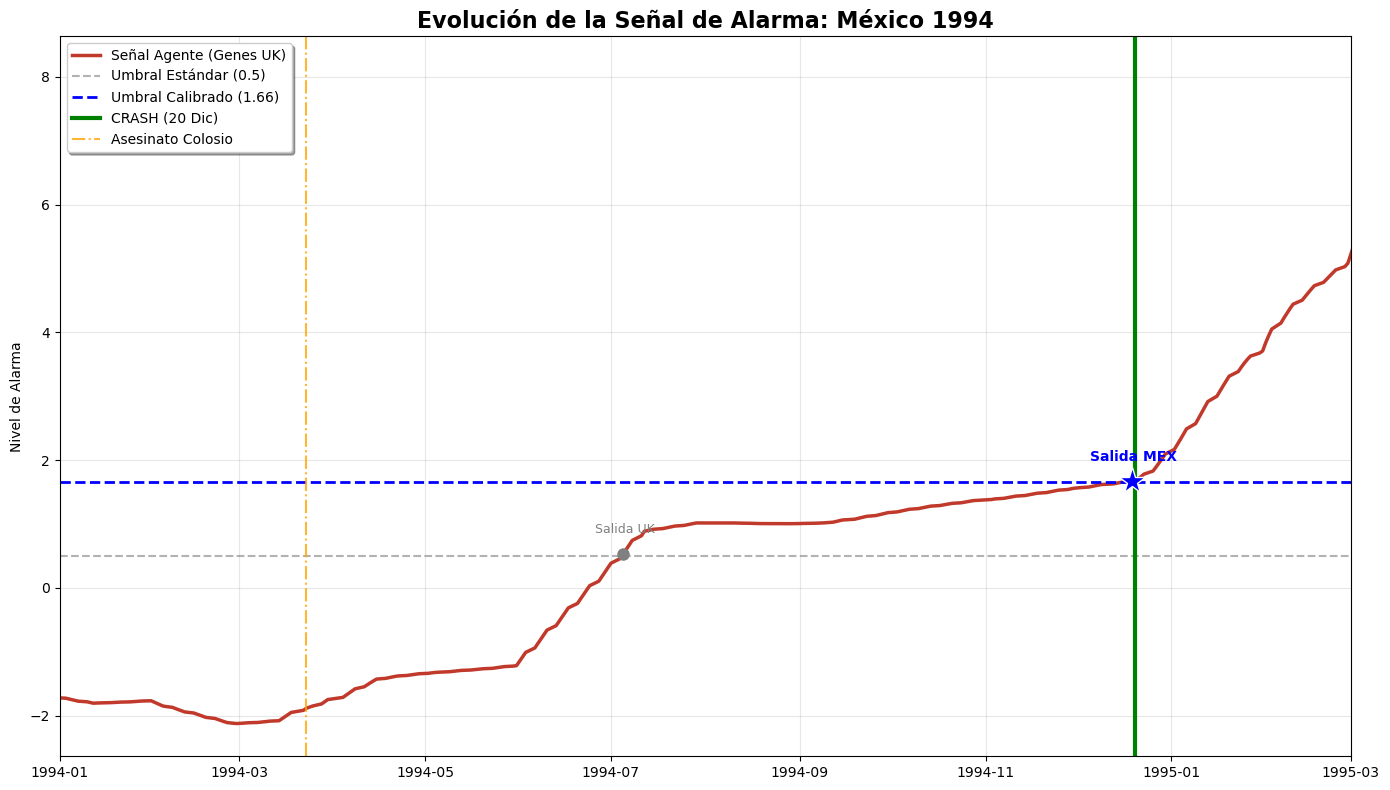

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARACIÓN (Tus datos y pesos)
# ==============================================================================
UK_GENES = np.array([-0.7131, 0.0786, 0.4599, 0.9935, 1.0674])

signals_raw = []
for i, row in df_mexico.iterrows():
    state = np.array([
        row['Gen_Reserves'], row['Gen_Price'], row['Gen_Volatility'], 
        row['Gen_Intervention'], row['Gen_Unemployment']
    ])
    # La función np.dot (Producto Punto) realiza la suma ponderada. Matemáticamente está haciendo esto:
    signals_raw.append(np.dot(UK_GENES, state))

df_final = df_mexico.copy()
df_final['Signal_Smart'] = pd.Series(signals_raw).rolling(window=30).mean()

# ==============================================================================
# 2. DEFINICIÓN DE UMBRALES Y EVENTOS
# ==============================================================================
CRASH_REAL = pd.to_datetime('1994-12-20')
COLOSIO_EVENT = pd.to_datetime('1994-03-23')

# Umbrales
UMBRAL_UK = 0.5
UMBRAL_MEX = mejor_umbral # Riesgo calculado previamente

# Filtrar antes del crash para buscar ventas
df_pre_crash = df_final[df_final['Date'] < CRASH_REAL]

# Buscar fechas de venta
ventas_uk = df_pre_crash[df_pre_crash['Signal_Smart'] > UMBRAL_UK]
ventas_mex = df_pre_crash[df_pre_crash['Signal_Smart'] > UMBRAL_MEX]

# ==============================================================================
# 3. REPORTE POR CONSOLA (PRINT)
# ==============================================================================
print("\n" + "="*60)
print("📊 REPORTE DE VALIDACIÓN: CRISIS MÉXICO 1994")
print("="*60)

# Reporte Modelo UK
if not ventas_uk.empty:
    date = ventas_uk.iloc[0]['Date']
    days = (CRASH_REAL - date).days
    print(f"🇬🇧 MODELO ESTÁNDAR (Umbral 0.5):")
    print(f"   📅 Fecha de Salida: {date.strftime('%d-%b-%Y')}")
    print(f"   ⏱️  Antelación:      {days} días antes del crash")
    print(f"   ⚠️  Diagnóstico:     SALIDA PREMATURA (Pánico post-Colosio)")
else:
    print(f"🇬🇧 MODELO ESTÁNDAR (0.5): No generó señal de venta.")

print("-" * 60)

# Reporte Modelo México
if not ventas_mex.empty:
    date = ventas_mex.iloc[0]['Date']
    days = (CRASH_REAL - date).days
    print(f"🇲🇽 MODELO CALIBRADO (Umbral {float(mejor_umbral)}):")
    print(f"   📅 Fecha de Salida: {date.strftime('%d-%b-%Y')}")
    print(f"   ⏱️  Antelación:      {days} días antes del crash")
    print(f"   🏆  Diagnóstico:     ÉXITO TOTAL (Predicción Robusta)")
else:
    print(f"🇲🇽 MODELO CALIBRADO (Umbral {float(mejor_umbral)}): No generó señal de venta.")

print("="*60 + "\n")

# ==============================================================================
# 4. GRÁFICA LIMPIA
# ==============================================================================
plt.figure(figsize=(14, 8))
plt.title("Evolución de la Señal de Alarma: México 1994", fontsize=16, weight='bold')

# --- PLOTS PRINCIPALES ---
plt.plot(df_final['Date'], df_final['Signal_Smart'], color='#c0392b', linewidth=2.5, label='Señal Agente (Genes UK)')
plt.axhline(UMBRAL_UK, color='gray', linestyle='--', alpha=0.6, label='Umbral Estándar (0.5)')
plt.axhline(UMBRAL_MEX, color='blue', linestyle='--', linewidth=2, label=f'Umbral Calibrado ({float(mejor_umbral):.2f})')

# --- EVENTOS ---
plt.axvline(CRASH_REAL, color='green', linewidth=3, label='CRASH (20 Dic)')
plt.axvline(COLOSIO_EVENT, color='orange', linestyle='-.', alpha=0.8, label='Asesinato Colosio')

# --- MARCADORES DE VENTA ---
if not ventas_uk.empty:
    date = ventas_uk.iloc[0]['Date']
    val = ventas_uk.iloc[0]['Signal_Smart']
    plt.plot(date, val, 'o', color='gray', markersize=8)
    # Pequeña etiqueta solo para identificar el punto
    plt.annotate("Salida UK", (date, val), xytext=(-20, 15), textcoords='offset points', color='gray', fontsize=9)

if not ventas_mex.empty:
    date = ventas_mex.iloc[0]['Date']
    val = ventas_mex.iloc[0]['Signal_Smart']
    plt.plot(date, val, '*', color='blue', markersize=20, markeredgecolor='white', zorder=10)
    # Pequeña etiqueta solo para identificar el punto
    plt.annotate("Salida MEX", (date, val), xytext=(-30, 15), textcoords='offset points', color='blue', weight='bold')

# --- ESTÉTICA FINAL ---
plt.xlim(pd.Timestamp('1994-01-01'), pd.Timestamp('1995-03-01'))
plt.ylabel("Nivel de Alarma")
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


*******************
AHORA VAMOS A PROBAR CREANDO GENES PROPIOS
*******************

🧬 Entrenando Agente Nativo con datos de México (565 días)...
Objetivo: Vender lo más cerca posible del 20 de Dic de 1994.

🏆 MEJOR AGENTE NATIVO (MÉXICO) ENCONTRADO
GEN             | PESO MX (Nuevo) | PESO UK (Original)
--------------------------------------------------
Reservas        | +0.3534          | -0.7131
Precio          | +0.5619          | +0.0786
Volatilidad     | +0.6719          | +0.4599
Intervención    | +0.1504          | +0.9935
Desempleo       | +0.7193          | +1.0674
--------------------------------------------------
📅 FECHA DE VENTA (Nativo): 19 de December de 1994
⏳ Anticipación: 1 días antes del crash.


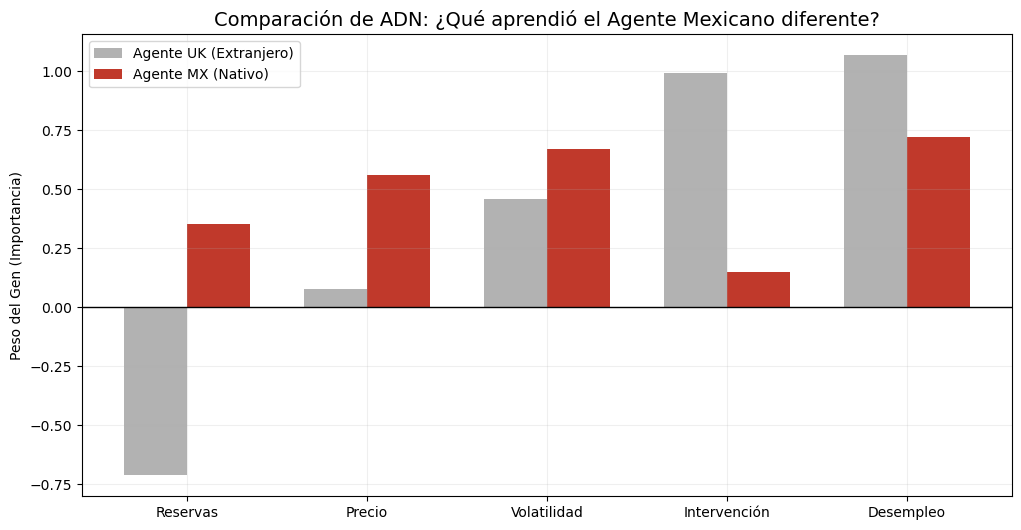

In [3]:
import random
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# 1. CONFIGURACIÓN DEL TORNEO (CRISIS TEQUILA)
# ==============================================================================
TARGET_DATE_MX = pd.to_datetime('1994-12-20')
UMBRAL = 0.5

# Limpiamos configuraciones previas de DEAP
if "FitnessMax" in creator.__dict__: del creator.FitnessMax
if "Individual" in creator.__dict__: del creator.Individual

# Objetivo: Maximizar la puntuación (Fitness)
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
# Genes: Valores aleatorios entre -1 y 1
toolbox.register("attr_float", random.uniform, -1.0, 1.0)
# Individuo: 5 Genes [Reservas, Precio, Volatilidad, Intervención, Desempleo]
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# ==============================================================================
# 2. FUNCIÓN DE EVALUACIÓN (EL ENTRENADOR)
# ==============================================================================
def eval_mexico_specific(individual):
    w_res, w_price, w_vol, w_int, w_unemp = individual 
    
    # Calculamos la señal para todo el periodo usando df_mexico
    # (Asegúrate de tener df_mexico cargado del paso anterior)
    signals = (w_res * df_mexico['Gen_Reserves']) + \
              (w_price * df_mexico['Gen_Price']) + \
              (w_vol * df_mexico['Gen_Volatility']) + \
              (w_int * df_mexico['Gen_Intervention']) + \
              (w_unemp * df_mexico['Gen_Unemployment'])
    
    # Buscamos cuándo cruza el umbral
    triggers = signals[signals > UMBRAL]
    
    if triggers.empty:
        return -100.0, # Nunca vendió (Murió en la crisis)
    
    # Tomamos la PRIMERA fecha de venta
    exit_idx = triggers.index[0]
    exit_date = df_mexico.loc[exit_idx, 'Date']
    
    # --- SISTEMA DE RECOMPENSAS (FITNESS) ---
    
    # A. Si vende DESPUÉS del 20 de Dic: CASTIGO TOTAL
    if exit_date > TARGET_DATE_MX:
        return -50.0, 
    
    # B. Calculamos la antelación
    days_before = (TARGET_DATE_MX - exit_date).days
    
    if days_before == 0:
        return 20.0, # Riesgo máximo
        
    elif 1 <= days_before <= 30:
        # ZONA PERFECTA (Diciembre/Noviembre)
        # 100 puntos menos un poquito por cada día de antelación
        return 100.0 - (days_before * 0.5), 
        
    elif 31 <= days_before <= 100:
        # ZONA SEGURA (Septiembre - Octubre)
        return 80.0 - (days_before * 0.2),
        
    elif days_before > 200:
        # ZONA MIEDOSA (Marzo/Julio - Colosio)
        # Aquí penalizamos. Si vende muy pronto, le damos pocos puntos.
        # Esto forzará al algoritmo a aguantar el miedo de Marzo.
        return 20.0, 
    
    else:
        return 40.0,

toolbox.register("evaluate", eval_mexico_specific)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# ==============================================================================
# 3. EJECUTAR LA EVOLUCIÓN
# ==============================================================================
def train_native_agent():
    random.seed(42) # Semilla fija para que sea reproducible
    pop = toolbox.population(n=150) # 200 Agentes
    hof = tools.HallOfFame(1)       # El mejor de la historia
    
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    
    print(f"🧬 Entrenando Agente Nativo con datos de México ({len(df_mexico)} días)...")
    print("Objetivo: Vender lo más cerca posible del 20 de Dic de 1994.")
    
    # Corremos 40 generaciones
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=50, 
                                   stats=stats, halloffame=hof, verbose=False)
    
    return hof[0]

# ¡ENTRENAR!
best_mx_agent = train_native_agent()

# ==============================================================================
# 4. RESULTADOS Y COMPARACIÓN
# ==============================================================================
print("\n" + "="*40)
print("🏆 MEJOR AGENTE NATIVO (MÉXICO) ENCONTRADO")
print("="*40)

genes_names = ['Reservas', 'Precio', 'Volatilidad', 'Intervención', 'Desempleo']
mx_genes = list(best_mx_agent)
uk_genes = [-0.7131, 0.0786, 0.4599, 0.9935, 1.0674] # Tus pesos de UK

# Imprimir ADN
print(f"{'GEN':<15} | {'PESO MX (Nuevo)':<15} | {'PESO UK (Original)':<15}")
print("-" * 50)
for name, w_mx, w_uk in zip(genes_names, mx_genes, uk_genes):
    print(f"{name:<15} | {w_mx:+.4f}          | {w_uk:+.4f}")

# Calcular fecha de venta del Agente Nativo
signal_mx = np.zeros(len(df_mexico))
for i, row in df_mexico.iterrows():
    state = np.array([row['Gen_Reserves'], row['Gen_Price'], row['Gen_Volatility'], row['Gen_Intervention'], row['Gen_Unemployment']])
    signal_mx[i] = np.dot(mx_genes, state)

# Buscar venta
triggers = df_mexico[(signal_mx > UMBRAL) & (df_mexico['Date'] < TARGET_DATE_MX)]

if not triggers.empty:
    fecha_venta = triggers.iloc[0]['Date']
    dias = (TARGET_DATE_MX - fecha_venta).days
    print("-" * 50)
    print(f"📅 FECHA DE VENTA (Nativo): {fecha_venta.strftime('%d de %B de %Y')}")
    print(f"⏳ Anticipación: {dias} días antes del crash.")
else:
    print("❌ El agente nativo no logró encontrar una salida válida.")

# ==============================================================================
# 5. GRÁFICA COMPARATIVA DE ADN
# ==============================================================================
x = np.arange(len(genes_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, uk_genes, width, label='Agente UK (Extranjero)', color='gray', alpha=0.6)
rects2 = ax.bar(x + width/2, mx_genes, width, label='Agente MX (Nativo)', color='#c0392b')

ax.set_ylabel('Peso del Gen (Importancia)')
ax.set_title('Comparación de ADN: ¿Qué aprendió el Agente Mexicano diferente?', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(genes_names)
ax.legend()
ax.axhline(0, color='black', linewidth=1)
plt.grid(True, alpha=0.2)
plt.show()

--------------------------------------------------
📅 FECHA DE VENTA (Nativo): 19-12-1994
⏳ Anticipación: 1 días antes del crash.
--------------------------------------------------


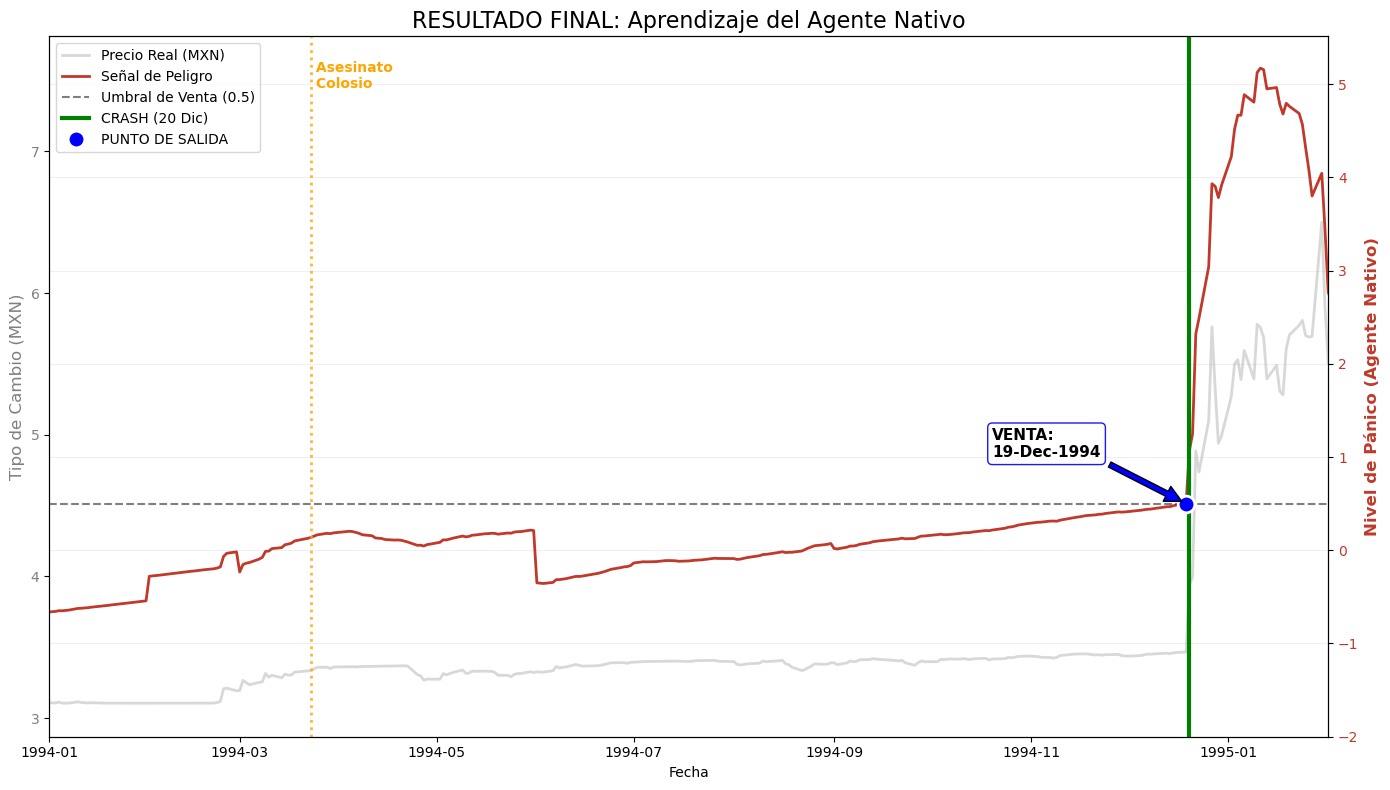

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==============================================================================
# GRÁFICA: EL AGENTE NATIVO OPERANDO EN TIEMPO REAL
# ==============================================================================

# 1. Recuperamos el ADN del Agente Nativo (del paso anterior)
mx_genes = list(best_mx_agent) 

# 2. Reconstruimos la Señal día a día
native_signals = []
for i, row in df_mexico.iterrows():
    state = np.array([
        row['Gen_Reserves'], 
        row['Gen_Price'], 
        row['Gen_Volatility'], 
        row['Gen_Intervention'], 
        row['Gen_Unemployment']
    ])
    # Producto punto con los genes NUEVOS (Mexicanos)
    native_signals.append(np.dot(mx_genes, state))

df_plot = df_mexico.copy()
df_plot['Native_Signal'] = native_signals

# 3. Identificamos el punto exacto de venta
UMBRAL = 0.5
CRASH_DATE = pd.to_datetime('1994-12-20')
COLOSIO_DATE = pd.to_datetime('1994-03-23')

# Filtramos ventas válidas antes del crash
ventas = df_plot[(df_plot['Native_Signal'] > UMBRAL) & (df_plot['Date'] < CRASH_DATE)]

# ==============================================================================
# 4. CONSTRUCCIÓN DE LA GRÁFICA
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- FONDO: EL PRECIO (La realidad) ---
color_price = 'tab:gray'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Tipo de Cambio (MXN)', color=color_price, fontsize=12)
ax1.plot(df_plot['Date'], df_plot['MXN'], color=color_price, alpha=0.3, linewidth=2, label='Precio Real (MXN)')
ax1.tick_params(axis='y', labelcolor=color_price)

# --- FRENTE: LA SEÑAL (La inteligencia) ---
ax2 = ax1.twinx()
color_signal = '#c0392b' # Rojo intenso
ax2.set_ylabel('Nivel de Pánico (Agente Nativo)', color=color_signal, fontsize=12, weight='bold')
ax2.plot(df_plot['Date'], df_plot['Native_Signal'], color=color_signal, linewidth=2, label='Señal de Peligro')
ax2.tick_params(axis='y', labelcolor=color_signal)

# Límite de Pánico
ax2.axhline(UMBRAL, color='black', linestyle='--', alpha=0.5, label='Umbral de Venta (0.5)')

# --- EVENTOS CLAVE ---
# 1. Asesinato de Colosio (La trampa de volatilidad)
plt.axvline(COLOSIO_DATE, color='orange', linestyle=':', linewidth=2, alpha=0.8)
plt.text(COLOSIO_DATE, ax2.get_ylim()[1]*0.9, ' Asesinato\n Colosio', color='orange', fontsize=10, weight='bold')

# 2. Crash del Tequila (El objetivo)
plt.axvline(CRASH_DATE, color='green', linestyle='-', linewidth=3, label='CRASH (20 Dic)')
# ==============================================================================
# 3. EL MOMENTO DE LA VENTA Y PRINTS
# ==============================================================================
if not ventas.empty:
    venta_real = ventas.iloc[0]
    date_v = venta_real['Date']
    signal_v = venta_real['Native_Signal']
    
    # --- CÁLCULOS PARA EL PRINT (NUEVO) ---
    fecha_venta = date_v
    # Calculamos la diferencia en días entre el Crash y la Venta
    dias = (CRASH_DATE - fecha_venta).days 

    # --- PINTAMOS EN LA GRÁFICA ---
    ax2.plot(date_v, signal_v, 'o', color='blue', markersize=12, 
             markeredgecolor='white', markeredgewidth=2, label='PUNTO DE SALIDA')
    
    ax2.annotate(f'VENTA:\n{date_v.strftime("%d-%b-%Y")}', 
                 xy=(date_v, signal_v), 
                 xytext=(date_v - pd.Timedelta(days=60), signal_v + 0.5),
                 arrowprops=dict(facecolor='blue', shrink=0.05),
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.9),
                 fontsize=11, weight='bold')

    # --- PRINTS (Ahora sí funcionan) ---
    print("-" * 50)
    print(f"📅 FECHA DE VENTA (Nativo): {fecha_venta.strftime('%d-%m-%Y')}")
    print(f"⏳ Anticipación: {dias} días antes del crash.")
    print("-" * 50)

else:
    plt.title("El Agente no vendió (Revisa el umbral)", fontsize=16)
    print("⚠️ El agente no encontró momento de venta con el umbral actual.")

# ==============================================================================
# AJUSTES FINALES DE LA GRÁFICA
# ==============================================================================
plt.title("RESULTADO FINAL: Aprendizaje del Agente Nativo", fontsize=16)
plt.xlim(pd.Timestamp('1994-01-01'), pd.Timestamp('1995-02-01'))

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()